In [62]:
import pandas as pd

In [63]:
df = pd.read_csv('https://raw.githubusercontent.com/danielAcl9/SpotifyRecommender/refs/heads/main/data/raw_data_spotify.csv')
df.head(5)

,artist,song,emotion,variance,Genre,Release Date,Key,Tempo,Loudness,Explicit,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness
0,ABBA,She's My Kind Of Girl,joy,0.447619,pop,2014,F Maj,128,-6.00,No,31,78,56,60,3,31,7,0
1,ABBA,"Andante, Andante",love,0.202222,pop,1980,A# Maj,102,-10.72,No,59,36,52,38,2,7,68,0
2,ABBA,As Good As New,sadness,0.300881,pop,1979,E Maj,139,-5.70,No,50,78,85,97,3,8,20,2
3,ABBA,Bang,joy,0.355000,pop,1975,F Maj,132,-3.00,No,52,76,50,89,3,32,3,0
4,ABBA,Bang-A-Boomerang,joy,0.355000,pop,1975,F Maj,132,-3.00,No,52,76,50,89,3,32,3,0


In [64]:
# Drop Key column as is not needed for this analysis
df.drop(columns=['Key'], inplace=True)

# Rename columns to lowercase and replace spaces with underscores
df.rename(columns={
    'Genre': 'genre',
    'Release Year': 'release_year',
    'Tempo': 'tempo',
    'Loudness': 'loudness',
    'Explicit': 'explicit',
    'Popularity': 'popularity',
    'Energy': 'energy',
    'Danceability': 'danceability',
    'Positiveness': 'positiveness',
    'Speechiness': 'speechiness',
    'Liveness': 'liveness',
    'Acousticness': 'acousticness',
    'Instrumentalness': 'instrumentalness'
}, inplace=True)

In [65]:
df.shape

(236988, 17)

In [66]:
df.dtypes

artist               object
song                 object
emotion              object
variance            float64
genre                object
Release Date          int64
tempo                 int64
loudness            float64
explicit             object
popularity            int64
energy                int64
danceability          int64
positiveness          int64
speechiness           int64
liveness              int64
acousticness          int64
instrumentalness      int64
dtype: object

In [67]:
df.isnull().sum()

artist              0
song                8
emotion             0
variance            0
genre               0
Release Date        0
tempo               0
loudness            0
explicit            0
popularity          0
energy              0
danceability        0
positiveness        0
speechiness         0
liveness            0
acousticness        0
instrumentalness    0
dtype: int64

In [68]:
df.dropna(inplace=True)
df.shape

(236980, 17)

### EDA

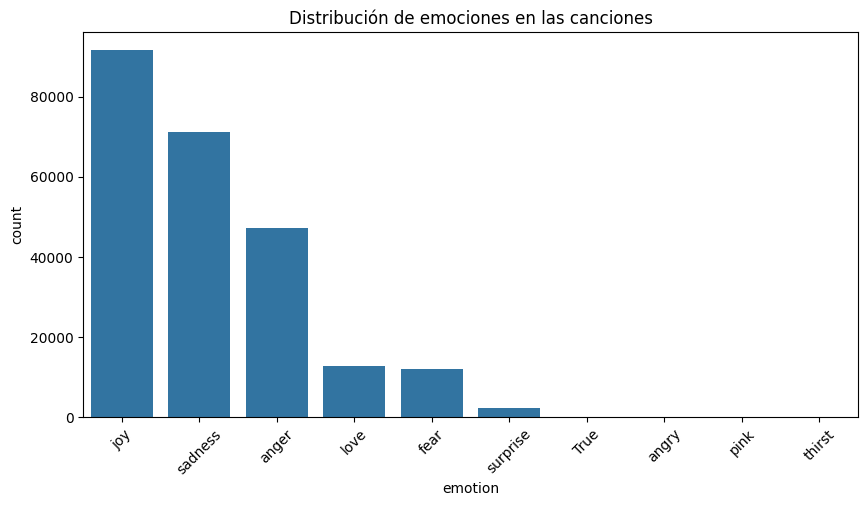

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)
plt.title('Distribución de emociones en las canciones')
plt.xticks(rotation=45)
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17236\2630896565.py:12: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USUARIO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


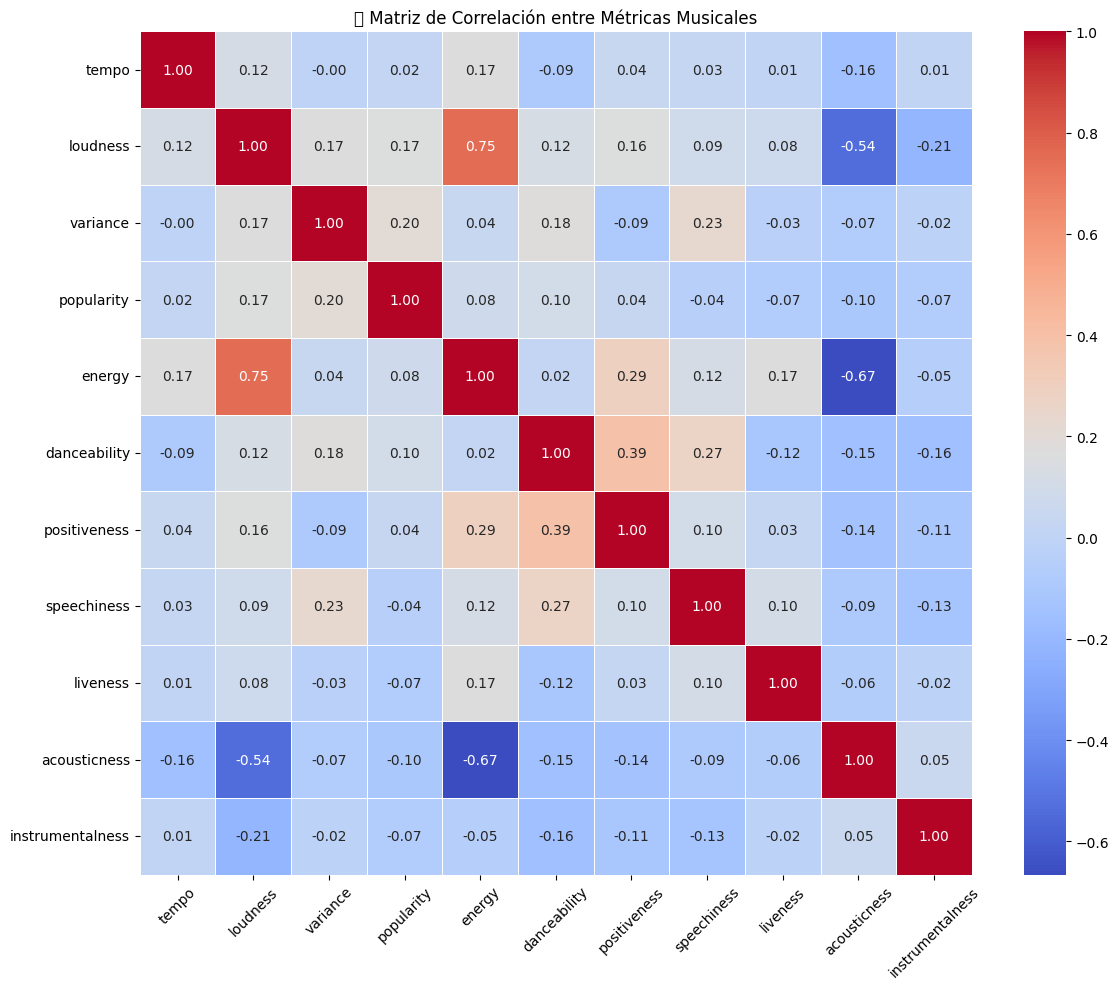

In [ ]:
# Seleccionamos solo las columnas numéricas
num_cols = [
    "tempo", "loudness", "variance", "popularity", "energy", "danceability",
    "positiveness", "speechiness", "liveness", "acousticness", "instrumentalness"
]

plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Métricas Musicales")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_17236\720534595.py:5: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USUARIO\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


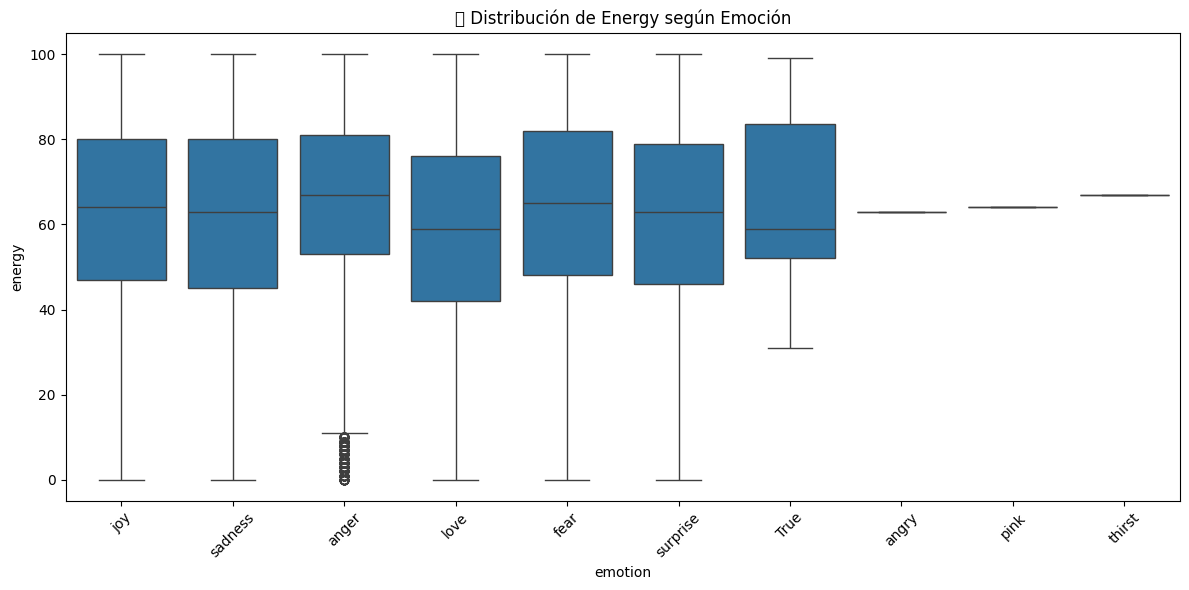

In [73]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="emotion", y="energy", order=df["emotion"].value_counts().index)
plt.title("🎧 Distribución de Energy según Emoción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()